## Import the essential libraries.

### 1. general settings
```python
from lib.contact_settings import *
```
In conttact settings are present the definition of necessary coefficients for the simulations together with definitions of paths for the wheel and rail profiles.

### 2. materials properties
```python
from lib.contact_material import material
```
Import ```material``` class to handle material of wheel and rail, here friction is introduced. For the time being the wheel and rail are considered of the same material, therefore, the equivalent Young modulus is calculated as:
$$
\hat{E} = \frac{2E}{\left(1+\nu^2\right)}
$$

### 3. Wheel and Rail
```python
from lib.geoLib.contact_wheel_rail import wheel, rail
```
The ```wheel``` class is used to calculate wheel profiles and wheel radius in relation to the rail position. The class accepts wheel_profile, b0 (nominal semi-axis distance), r0 (nominal radius), and lr (RIGHT or LEFT). Nominal settings are: ```wheel_profile=S1002_profile, b0=0.75, r0=0.46, lr=RIGHT```.

The ```rail``` class is used to calculate rail profiles considering gauge and raiil inclination. The class accepts rail_profile, gauge, rail_inclination, and lr (RIGHT or LEFT). Nominal settings are: ```rail_profile=UIC60_profile, gauge=1.435, rail_inclination=40, lr=RIGHT```.

### 4. Dynamic states
```python
from lib.dynLib.contact_dyn_state import dynamic_state
```
The ```dynamic_state``` class is used to move the wheel over the rail. A proper dynamic calculation is under development and will use this class as support.

### 5. Normal contact methods
```python
from lib.normLib.contact_methods import eqv_el_normal_contact, kik_pyo_normal_contact
```
Two normal methods are foreseen, equivalent nomrla contact (```eqv_el_normal_contact```) and kik piotrowski contact (```kik_pyo_normal_contact```). Both inerit from the ```normal_contact``` class. No inputs have to be provided.

### 6. Normal contact sover
```python
from lib.normLib.contact_solver import NormalContactSolver
```
The ```NormalContactSolver``` class is used to solve the normal contact problem given a contact method and a numer of contact patches to solve the problem for. The cass accepts the class ```eqv_el_normal_contact``` or ```kik_pyo_normal_contact```, and ```numer_of_patches```. The default number of patches is 3.

In [1]:
from lib.contact_settings import *
from lib.contact_material import material
from lib.geoLib.contact_wheel_rail import wheel, rail
from lib.dynLib.contact_dyn_state import dynamic_state
from lib.normLib.contact_methods import eqv_el_normal_contact, kik_pio_normal_contact
from lib.normLib.contact_solver import NormalContactSolver

## Initialize Wheels and Rails

LEFT and RIGHT are keywords setted in ```lib.contact_settings```. When defining the objects Wheel and Rail, they are automatically set to theier starting positions given if they are left or right, gauge and semiaxis distance.

In [2]:
Wheel_R, Wheel_L = wheel(), wheel(lr=LEFT)
Rail_R, Rail_L = rail(), rail(lr=LEFT)

Let's plot them in their location

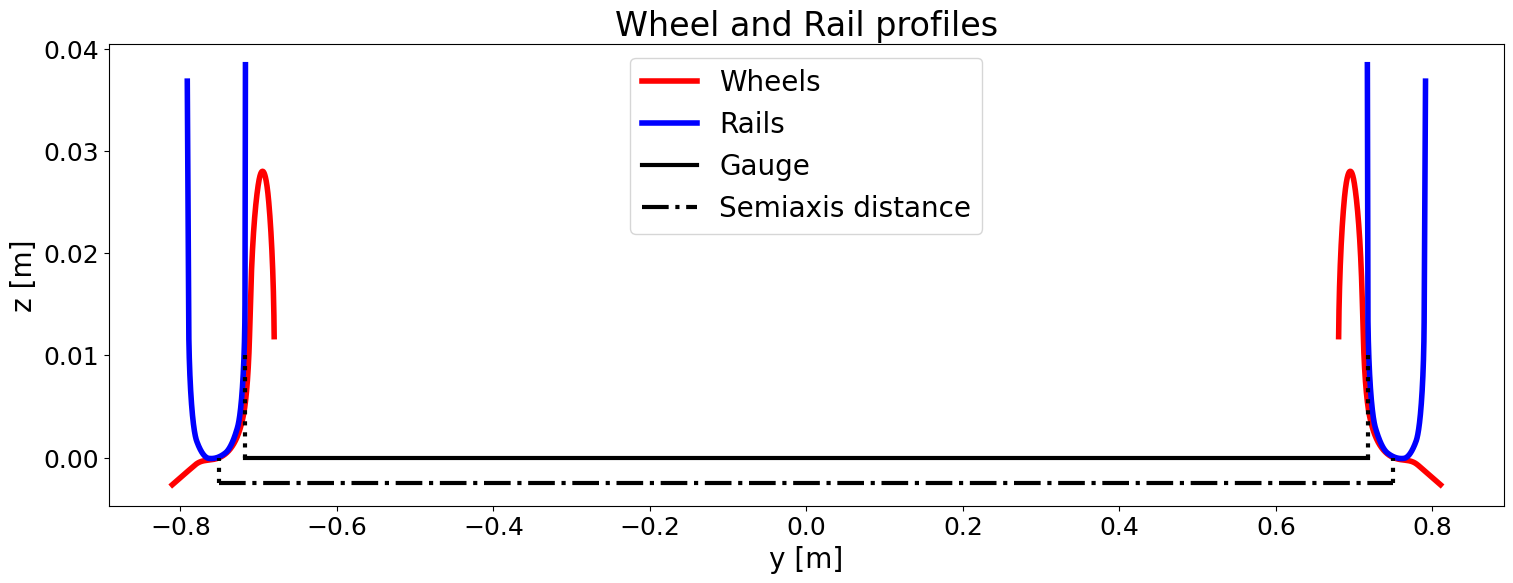

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(18, 6))


ax.plot(
    Wheel_L.wheel_start_pos[:, 0],
    Wheel_L.wheel_start_pos[:, 1],
    color="red",
    label="Wheels",
    linewidth=4,
)
ax.plot(
    Wheel_R.wheel_start_pos[:, 0],
    Wheel_R.wheel_start_pos[:, 1],
    color="red",
    linewidth=4,
)

ax.plot(
    Rail_L.rail_start_pos[:, 0],
    Rail_L.rail_start_pos[:, 1],
    color="blue",
    label="Rails",
    linewidth=4,
)
ax.plot(
    Rail_R.rail_start_pos[:, 0], Rail_R.rail_start_pos[:, 1], color="blue", linewidth=4
)

ax.plot(
    [-Rail_L.gauge / 2, Rail_L.gauge / 2],
    [0, 0],
    color="black",
    label="Gauge",
    linewidth=3,
)
ax.plot(
    [-Rail_L.gauge / 2, -Rail_L.gauge / 2],
    [0.01, 0],
    linestyle=":",
    color="black",
    linewidth=3,
)
ax.plot(
    [Rail_L.gauge / 2, Rail_L.gauge / 2],
    [0.01, 0],
    linestyle=":",
    color="black",
    linewidth=3,
)

ax.plot(
    [-Wheel_L.b0, Wheel_L.b0],
    [-0.0025, -0.0025],
    linestyle="-.",
    color="black",
    label="Semiaxis distance",
    linewidth=3,
)

ax.plot(
    [-Wheel_L.b0, -Wheel_L.b0],
    [-0.0025, 0],
    linestyle=":",
    color="black",
    linewidth=3,
)
ax.plot(
    [Wheel_L.b0, Wheel_L.b0],
    [-0.0025, 0],
    linestyle=":",
    color="black",
    linewidth=3,
)

ax.legend(fontsize=20)
ax.set_xlabel("y [m]", fontsize=20)
ax.set_ylabel("z [m]", fontsize=20)
ax.set_title("Wheel and Rail profiles", fontsize=24)
ax.tick_params(axis='both', labelsize=18)

plt.show()

## Calculate Static Contact

Now that we have initialized the wheels and rails, it is possible to calculate the static contact for different positions of the wheel with respect to the rail.

To do so, it is necessery to initialize material properties and the contact patch method together with the contact solver. Here it is also necessary to define how many contact patches are foreseen to be active. It is recommended to use at least 3.

The ```NormalContactSolver``` has 3 properties .contact_model, .n_patches, .contact_patches. The is a list of .n_patches objects of type .contact_model where the results for each contact patch will be saved

Let's start with the Equivalent contact model.


In [4]:
material_model = material()

n_patches = 3
contact_eq = NormalContactSolver(eqv_el_normal_contact(), n_patches)

Let's define a suitable position for the wheel with respect to the rail.

```set_dynamic_state()``` assign the new state to the wheel.
```calculate_position``` move the profile to the new location.

In [5]:
new_state = dynamic_state(state_z=1e-4)
Wheel_L.set_dynamic_state(new_state)
Wheel_L.calculate_position()

### Calculate contact

The calss ```NormalContactSolver``` has a method ```patch_search``` that calculates the values of the normal contact and assign them to the correct patch in the patch list ```contact_patches``` defined during the initiaization of ```contact_eq```.
The inputs are the Wheel object, the Rail object, and the material object.

In [6]:
contact_eq.patch_search(Wheel_L, Rail_L, material_model)

Let's check the obtained values for the normal contac of the three defined contact patches. Let's check the normal force, the contact angle, the Q and Y forces, and a and b semi axis of the elliptical contact patch.

If one of the defined contact patch has not found a contact, all the values are set to zero. In the position selected for the wheel, only one contact patch is active, therefore there is only one contact point.

In [7]:
data = []

for jj in range(contact_eq.n_patches):

    data.append(
        [
            contact_eq.contact_patches[jj].normal_force,
            contact_eq.contact_patches[jj].contact_angle,
            contact_eq.contact_patches[jj].Q_force,
            contact_eq.contact_patches[jj].Y_force,
            contact_eq.contact_patches[jj].semi_axis_a*1e3,
            contact_eq.contact_patches[jj].semi_axis_b*1e3,
        ]
    )

print(f"{'Normal force [N]':<20} {'Contact angle [deg]':<20} {'Q force [N]':<20} {'Y force [N]':<20} {'ellips a [mm]':<20} {'ellips b [mm]':<20}")
for row in data:
    print(f"{row[0]:<20.2f} {row[1]:<20.2f} {row[2]:<20.2f} {row[3]:<20.2f} {row[4]:<20.2f} {row[5]:<20.2f}")


Normal force [N]     Contact angle [deg]  Q force [N]          Y force [N]          ellips a [mm]        ellips b [mm]       
13291.75             -0.04                13282.92             -484.53              3.23                 8.24                
0.00                 0.00                 0.00                 0.00                 0.00                 0.00                
0.00                 0.00                 0.00                 0.00                 0.00                 0.00                


### Import and use the function Static Contact

```python
from calc_routines.determine_static_contact import static_contact
```

This function is used to calculate the contact quantities varying the lateral position of the wheel over the rail given a constant Q force to balance.

To do so it is necessery to define an array of lateral displacements of the wheel.
the ```static_contact``` takes in input the displacements array, the Wheel and Rail objects, and the material object. Additional inputs are, the patch discretization (default 58), the Q force to be solve the contact for (default 50 kN), and a tolerance to stop the search (default 50 N). Additionally, it is possible to add a solver method for the balance of the Q force as per the ```scipy.optimize``` ```root``` solver.

The function provides two dictionaries whith a key for each contact patch. Depending on the contact method used the two dictionaries are filled with arrays of different quantities. In case equivalent elestic contact is selected, the pressure dstribution dictionary is empty.

In [8]:
from calc_routines.determine_static_contact import static_contact

dy = 0.05e-3
deltays = np.arange(-20e-3, 20e-3 + dy, dy)

patches_per_deltays_eq, result_state_pressure_eq = static_contact(
    deltays, Wheel_R, Rail_R, contact_eq, material_model
)

100%|██████████| 801/801 [00:24<00:00, 33.16it/s]


Let's plot some of the results.

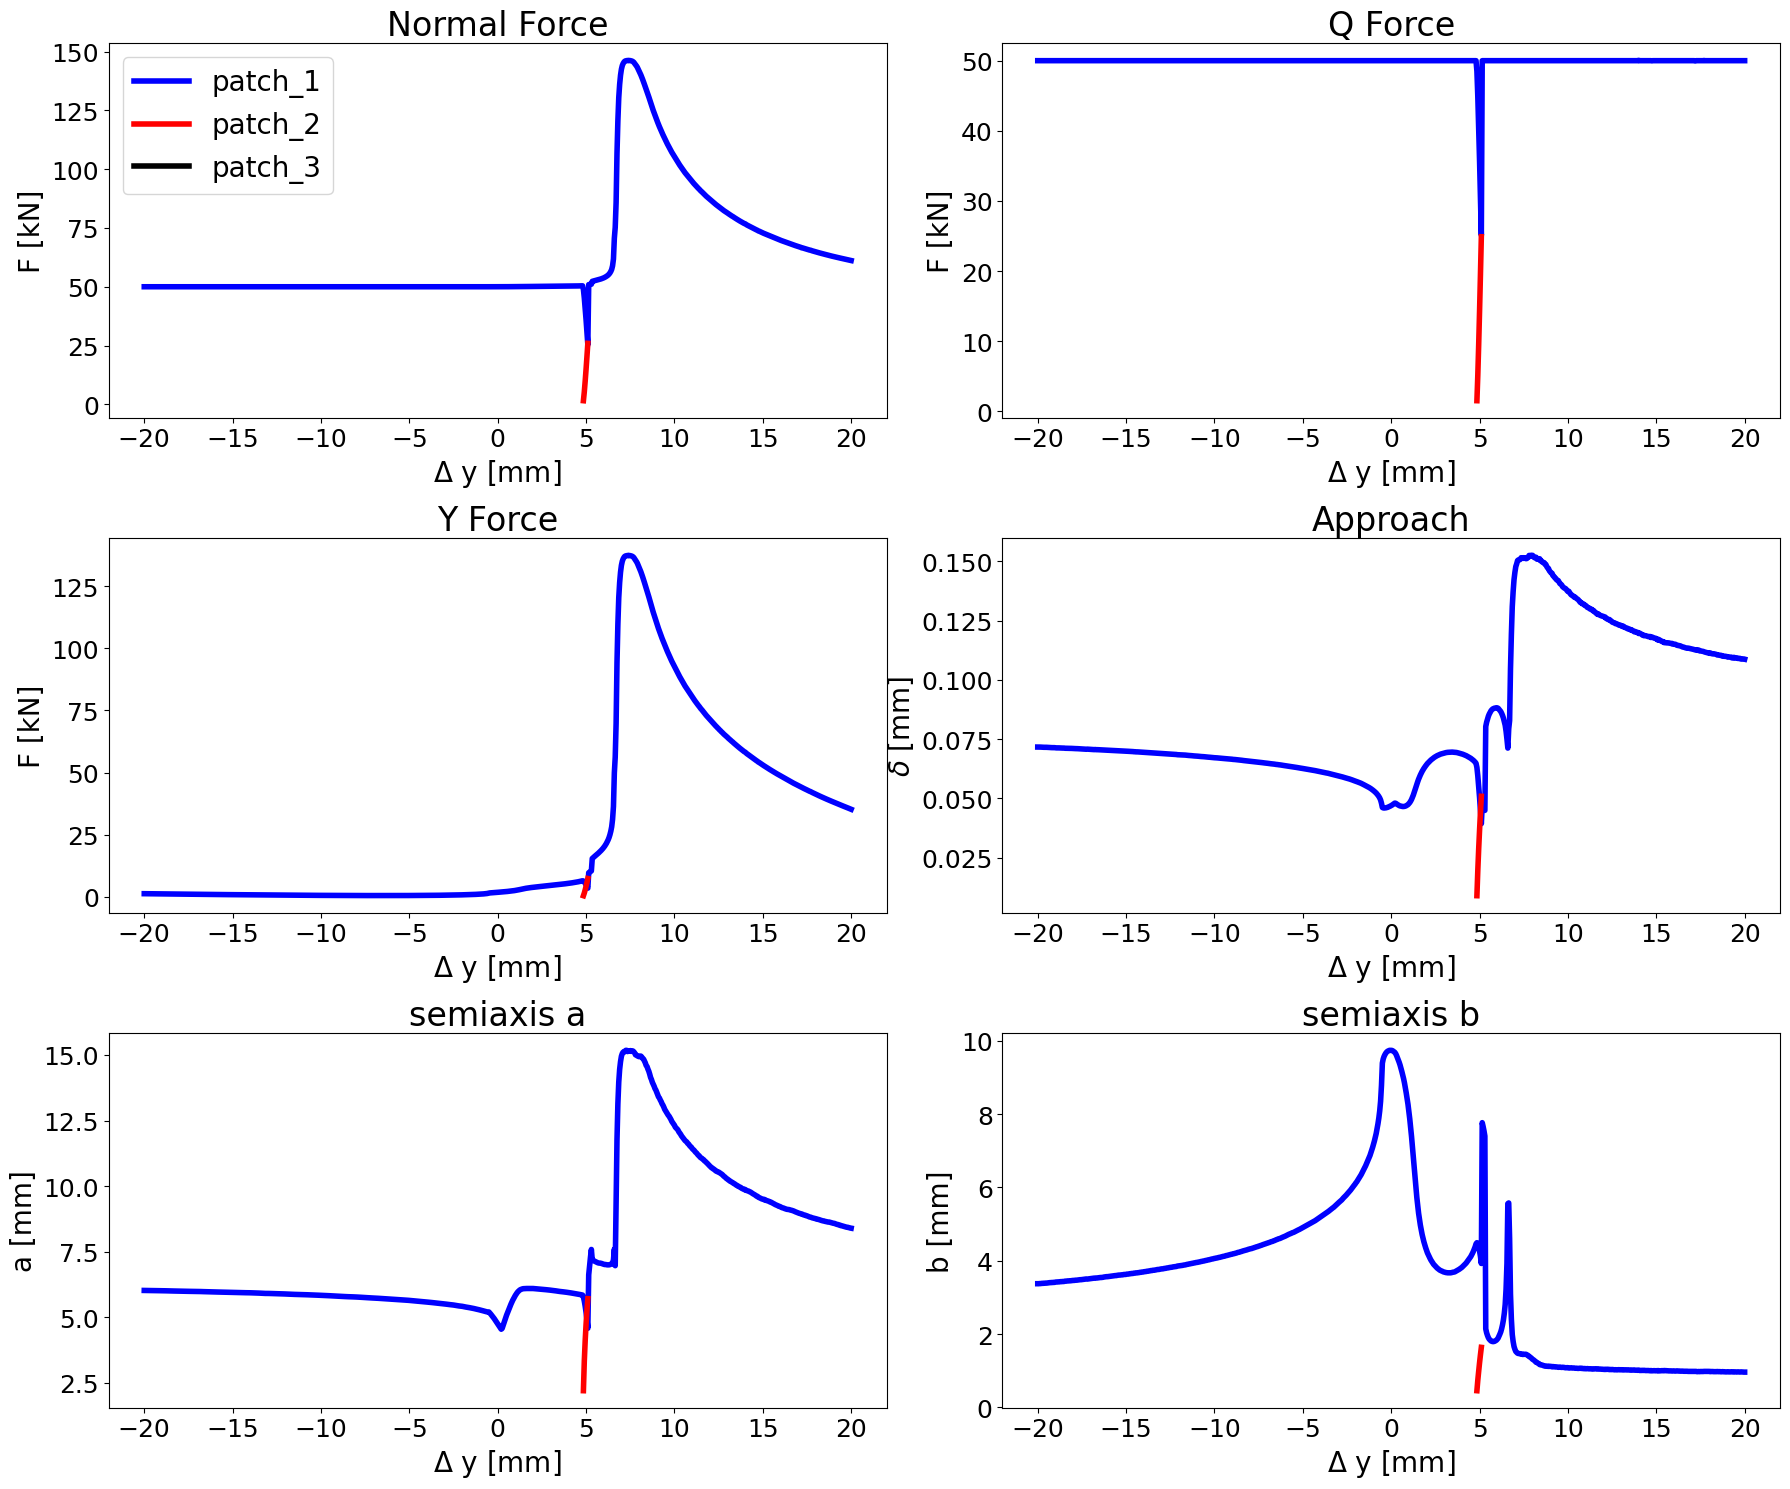

In [9]:
fig, ax = plt.subplots(ncols=2, nrows=3, figsize=(18, 15))

colors = ["blue", "red", "black"]
for jj in range(n_patches):
    # Normal Forces
    indexes = np.where(patches_per_deltays_eq[f"patch_{jj}"][:, 1] != 0)[0]
    ax[0,0].plot(
        deltays[indexes]*1e3,
        patches_per_deltays_eq[f"patch_{jj}"][indexes, 1]*1e-3,
        color=colors[jj],
        label=f"patch_{jj+1}",
        linewidth=4,
    )
    ax[0,0].legend(fontsize=20)
    ax[0,0].set_xlabel(r"$\Delta$ y [mm]", fontsize=20)
    ax[0,0].set_ylabel("F [kN]", fontsize=20)
    ax[0,0].set_title("Normal Force", fontsize=24)
    ax[0,0].tick_params(axis='both', labelsize=18)
    
    # Q Force
    indexes = np.where(patches_per_deltays_eq[f"patch_{jj}"][:, 2] != 0)[0]
    ax[0,1].plot(
        deltays[indexes]*1e3,
        patches_per_deltays_eq[f"patch_{jj}"][indexes, 2]*1e-3,
        color=colors[jj],
        linewidth=4,
    )
    ax[0,1].set_xlabel(r"$\Delta$ y [mm]", fontsize=20)
    ax[0,1].set_ylabel("F [kN]", fontsize=20)
    ax[0,1].set_title("Q Force", fontsize=24)
    ax[0,1].tick_params(axis='both', labelsize=18)
    
    # Y Force
    indexes = np.where(patches_per_deltays_eq[f"patch_{jj}"][:, 3] != 0)[0]
    ax[1,0].plot(
        deltays[indexes]*1e3,
        patches_per_deltays_eq[f"patch_{jj}"][indexes, 3]*1e-3,
        color=colors[jj],
        linewidth=4,
    )
    ax[1,0].set_xlabel(r"$\Delta$ y [mm]", fontsize=20)
    ax[1,0].set_ylabel("F [kN]", fontsize=20)
    ax[1,0].set_title("Y Force", fontsize=24)
    ax[1,0].tick_params(axis='both', labelsize=18)
    
    # Approach
    indexes = np.where(patches_per_deltays_eq[f"patch_{jj}"][:, 4] != 0)[0]
    ax[1,1].plot(
        deltays[indexes]*1e3,
        patches_per_deltays_eq[f"patch_{jj}"][indexes, 4]*1e3,
        color=colors[jj],
        linewidth=4,
    )
    ax[1,1].set_xlabel(r"$\Delta$ y [mm]", fontsize=20)
    ax[1,1].set_ylabel(r"$\delta$ [mm]", fontsize=20)
    ax[1,1].set_title("Approach", fontsize=24)
    ax[1,1].tick_params(axis='both', labelsize=18)
    
    # a
    indexes = np.where(patches_per_deltays_eq[f"patch_{jj}"][:, 6] != 0)[0]
    ax[2,0].plot(
        deltays[indexes]*1e3,
        patches_per_deltays_eq[f"patch_{jj}"][indexes, 6]*1e3,
        color=colors[jj],
        linewidth=4,
    )
    ax[2,0].set_xlabel(r"$\Delta$ y [mm]", fontsize=20)
    ax[2,0].set_ylabel("a [mm]", fontsize=20)
    ax[2,0].set_title("semiaxis a", fontsize=24)
    ax[2,0].tick_params(axis='both', labelsize=18)
    
    # b
    indexes = np.where(patches_per_deltays_eq[f"patch_{jj}"][:, 7] != 0)[0]
    ax[2,1].plot(
        deltays[indexes]*1e3,
        patches_per_deltays_eq[f"patch_{jj}"][indexes, 7]*1e3,
        color=colors[jj],
        linewidth=4,
    )
    ax[2,1].set_xlabel(r"$\Delta$ y [mm]", fontsize=20)
    ax[2,1].set_ylabel("b [mm]", fontsize=20)
    ax[2,1].set_title("semiaxis b", fontsize=24)
    ax[2,1].tick_params(axis='both', labelsize=18)

fig.tight_layout()


### Repeat for the Kik-Piotrowski method

Let's initialize a ```NormalContactSolver``` object with 3 contact patches and the ```kik_pio_normal_contact``` method.

**N.B.:** the number of contact patches is 3 times the number of the input contact patches due to the method implementation.

In [10]:
n_patches = 3
contact_kp = NormalContactSolver(kik_pio_normal_contact(), n_patches)

contact_kp.patch_search(Wheel_L, Rail_L, material_model)

Let's check the same results that was checked for the equivalent contact method.

In [11]:
data = []

for jj in range(contact_kp.n_patches):

    data.append(
        [
            contact_kp.contact_patches[jj].normal_force,
            contact_kp.contact_patches[jj].contact_angle,
            contact_kp.contact_patches[jj].Q_force,
            contact_kp.contact_patches[jj].Y_force,
        ]
    )

print(f"{'Normal force [N]':<20} {'Contact angle [deg]':<20} {'Q force [N]':<20} {'Y force [N]':<20}")
for row in data:
    print(f"{row[0]:<20.2f} {row[1]:<20.2f} {row[2]:<20.2f} {row[3]:<20.2f}")


Normal force [N]     Contact angle [deg]  Q force [N]          Y force [N]         
2636.51              -0.04                2634.76              -96.11              
0.00                 0.00                 0.00                 0.00                
0.00                 0.00                 0.00                 0.00                
0.00                 0.00                 0.00                 0.00                
0.00                 0.00                 0.00                 0.00                
0.00                 0.00                 0.00                 0.00                
0.00                 0.00                 0.00                 0.00                
0.00                 0.00                 0.00                 0.00                
0.00                 0.00                 0.00                 0.00                


Let's check again the static contact as the wheel shifts across the rail while maintaining a constant Q force. Be patient it may take a while.

In [12]:
Wheel_R, Rail_R = wheel(), rail()

patches_per_deltays_kp, result_state_pressure_kp = static_contact(
    deltays, Wheel_R, Rail_R, contact_kp, material_model
)

 63%|██████▎   | 507/801 [01:14<22:23,  4.57s/it]c:\Users\rocco\Desktop\PPP\prove\gitRepo\SimRail\lib\normLib\contact_methods.py:241: RuntimeWarning: invalid value encountered in sqrt
  search_matrix_1[jj, valid_x] = np.sqrt(
100%|██████████| 801/801 [02:04<00:00,  6.45it/s]


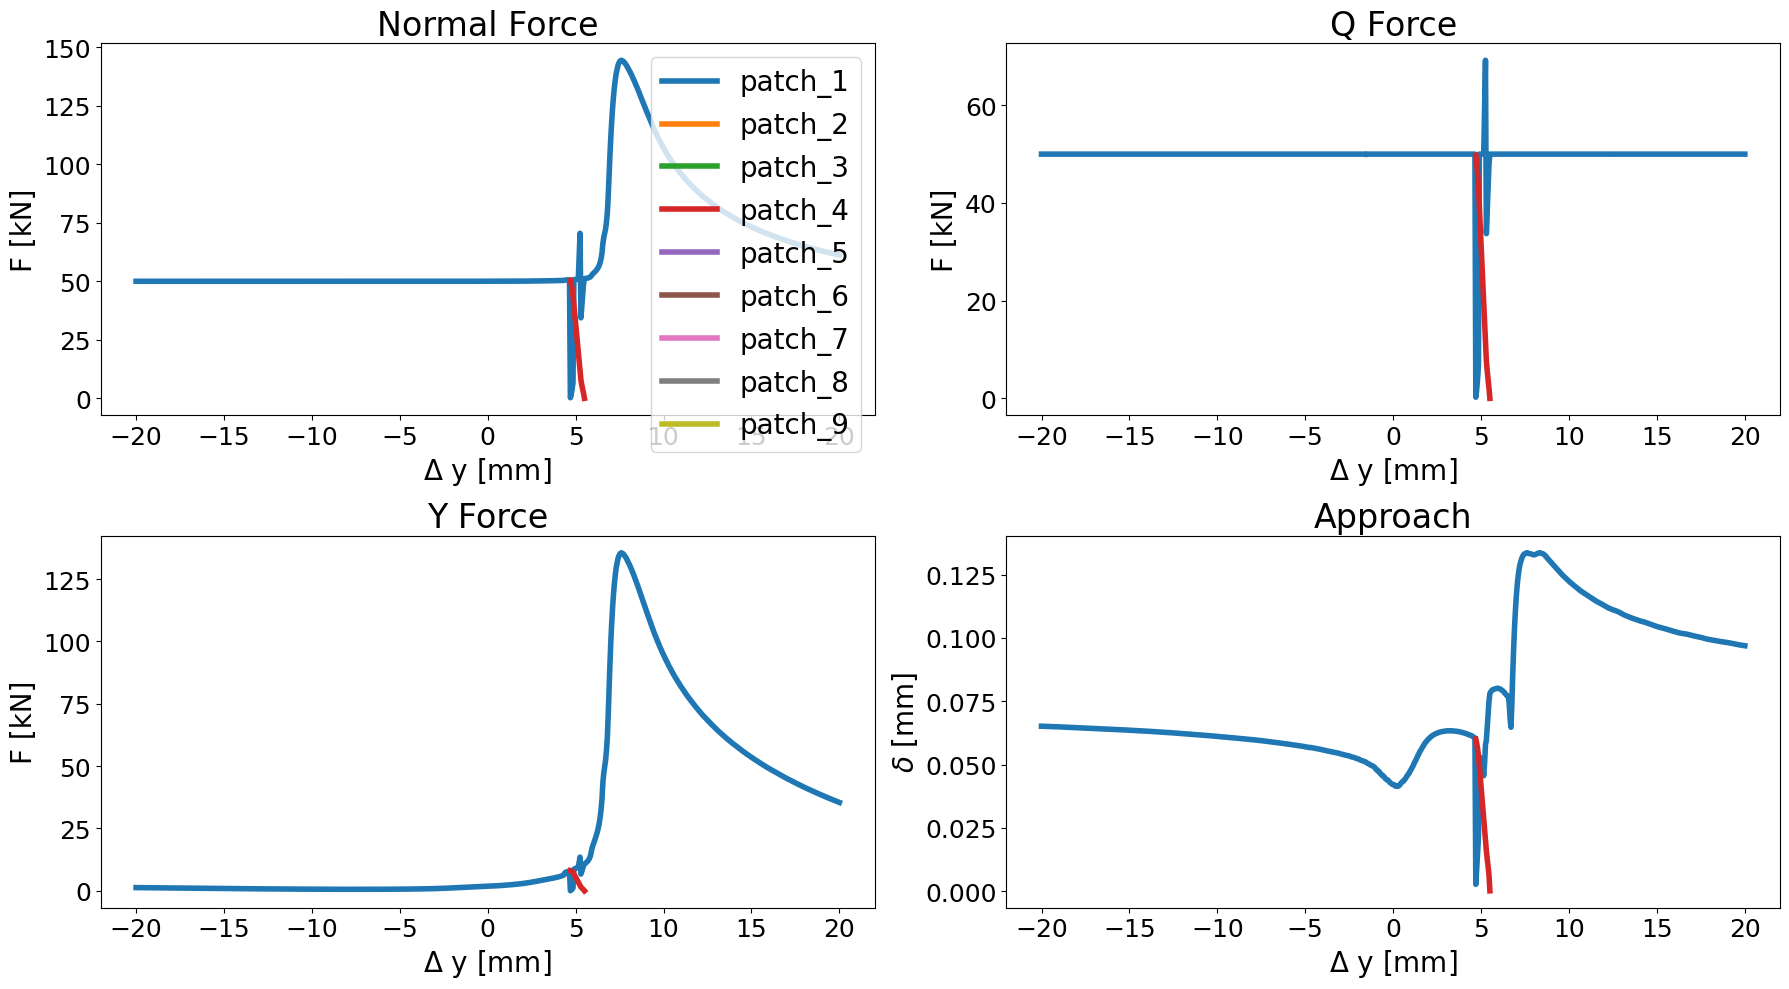

In [13]:
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(18, 10))

colors = ["blue", "red", "black"]
for jj in range(n_patches*3):
    # Normal Forces
    indexes = np.where(patches_per_deltays_kp[f"patch_{jj}"][:, 1] != 0)[0]
    ax[0,0].plot(
        deltays[indexes]*1e3,
        patches_per_deltays_kp[f"patch_{jj}"][indexes, 1]*1e-3,
        # color=colors[jj],
        label=f"patch_{jj+1}",
        linewidth=4,
    )
    ax[0,0].legend(fontsize=20)
    ax[0,0].set_xlabel(r"$\Delta$ y [mm]", fontsize=20)
    ax[0,0].set_ylabel("F [kN]", fontsize=20)
    ax[0,0].set_title("Normal Force", fontsize=24)
    ax[0,0].tick_params(axis='both', labelsize=18)
    
    # Q Force
    indexes = np.where(patches_per_deltays_kp[f"patch_{jj}"][:, 2] != 0)[0]
    ax[0,1].plot(
        deltays[indexes]*1e3,
        patches_per_deltays_kp[f"patch_{jj}"][indexes, 2]*1e-3,
        # color=colors[jj],
        linewidth=4,
    )
    ax[0,1].set_xlabel(r"$\Delta$ y [mm]", fontsize=20)
    ax[0,1].set_ylabel("F [kN]", fontsize=20)
    ax[0,1].set_title("Q Force", fontsize=24)
    ax[0,1].tick_params(axis='both', labelsize=18)
    
    # Y Force
    indexes = np.where(patches_per_deltays_kp[f"patch_{jj}"][:, 3] != 0)[0]
    ax[1,0].plot(
        deltays[indexes]*1e3,
        patches_per_deltays_kp[f"patch_{jj}"][indexes, 3]*1e-3,
        # color=colors[jj],
        linewidth=4,
    )
    ax[1,0].set_xlabel(r"$\Delta$ y [mm]", fontsize=20)
    ax[1,0].set_ylabel("F [kN]", fontsize=20)
    ax[1,0].set_title("Y Force", fontsize=24)
    ax[1,0].tick_params(axis='both', labelsize=18)
    
    # Approach
    indexes = np.where(patches_per_deltays_kp[f"patch_{jj}"][:, 4] != 0)[0]
    ax[1,1].plot(
        deltays[indexes]*1e3,
        patches_per_deltays_kp[f"patch_{jj}"][indexes, 4]*1e3,
        # color=colors[jj],
        linewidth=4,
    )
    ax[1,1].set_xlabel(r"$\Delta$ y [mm]", fontsize=20)
    ax[1,1].set_ylabel(r"$\delta$ [mm]", fontsize=20)
    ax[1,1].set_title("Approach", fontsize=24)
    ax[1,1].tick_params(axis='both', labelsize=18)

fig.tight_layout()


### Compare the results

First it is possible to compare the difference in the normal force and approach between the two methods.

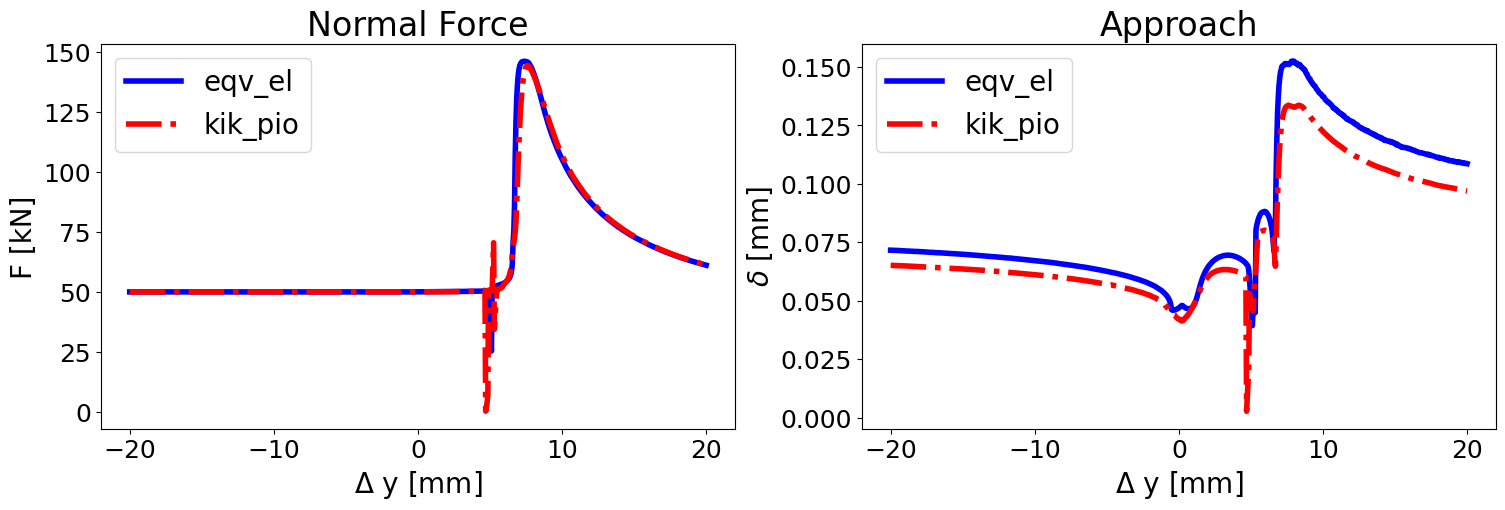

In [14]:
fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(18, 5))

# Comparison of normal force
indexes = np.where(patches_per_deltays_eq[f"patch_{0}"][:, 1] != 0)[0]
ax[0].plot(
    deltays[indexes]*1e3,
    patches_per_deltays_eq[f"patch_{0}"][indexes, 1]*1e-3,
    label=f"eqv_el",
    color="blue",
    linewidth=4,
)
indexes = np.where(patches_per_deltays_kp[f"patch_{0}"][:, 1] != 0)[0]
ax[0].plot(
    deltays[indexes]*1e3,
    patches_per_deltays_kp[f"patch_{0}"][indexes, 1]*1e-3,
    label=f"kik_pio",
    linestyle="-.",
    color="red",
    linewidth=4,
)
ax[0].legend(fontsize=20)
ax[0].set_xlabel(r"$\Delta$ y [mm]", fontsize=20)
ax[0].set_ylabel("F [kN]", fontsize=20)
ax[0].set_title("Normal Force", fontsize=24)
ax[0].tick_params(axis='both', labelsize=18)

# Comparison of approach
indexes = np.where(patches_per_deltays_eq[f"patch_{0}"][:, 4] != 0)[0]
ax[1].plot(
    deltays[indexes]*1e3,
    patches_per_deltays_eq[f"patch_{0}"][indexes, 4]*1e3,
    label=f"eqv_el",
    color="blue",
    linewidth=4,
)
indexes = np.where(patches_per_deltays_kp[f"patch_{0}"][:, 4] != 0)[0]
ax[1].plot(
    deltays[indexes]*1e3,
    patches_per_deltays_kp[f"patch_{0}"][indexes, 4]*1e3,
    label=f"kik_pio",
    linestyle="-.",
    color="red",
    linewidth=4,
)
ax[1].legend(fontsize=20)
ax[1].set_xlabel(r"$\Delta$ y [mm]", fontsize=20)
ax[1].set_ylabel(r"$\delta$ [mm]", fontsize=20)
ax[1].set_title("Approach", fontsize=24)
ax[1].tick_params(axis='both', labelsize=18)

Let's now check how the two models handel the presence of 2 contact patches.

In [15]:
import matplotlib.pyplot as plt


def plot(
    patches_per_deltays_kp,
    result_state_pressure_kp,
    patches_per_deltays_eq,
    dy_solve,
    plot_index,
):

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 4))

    for jj in range(2):

        ax = axes[jj]

        b_ = np.linspace(
            -patches_per_deltays_eq[f"patch_{jj}"][plot_index, 7],
            patches_per_deltays_eq[f"patch_{jj}"][plot_index, 7],
            58,
        )
        a_ = patches_per_deltays_eq[f"patch_{jj}"][plot_index, 6] * np.sqrt(
            1 - (b_**2) / (patches_per_deltays_eq[f"patch_{jj}"][plot_index, 7] ** 2)
        )

        patch_pressure = result_state_pressure_kp[f"patch_{jj*3}"][
            58 * (plot_index) : 58 * (plot_index + 1), 0 : 58 + 2
        ]

        Y, X = np.meshgrid(
            patch_pressure[:,1], patch_pressure[:,0]
        )
        data_1 = patch_pressure[:,2:]
        data_1 = np.where(data_1 == 0, np.nan, data_1)

        if data_1.size != 1:
            pcm = ax.pcolormesh(
                Y * 1e3, X * 1e3, np.transpose(data_1), shading="auto", cmap="inferno"
            )
        ax.plot(b_ * 1e3, a_ * 1e3, color="black", linewidth=4)
        ax.plot(b_ * 1e3, -a_ * 1e3, color="black", linewidth=4)

        if data_1.size != 1:
            cbar = fig.colorbar(pcm, ax=ax)
            cbar.set_label("Pressure", fontsize=20)
            cbar.ax.tick_params(labelsize=18)

        textstr = "\n".join(
            (
                "Kik Pio. N [kN]: %.2f"
                % (patches_per_deltays_kp[f"patch_{jj*3}"][plot_index, 1] / 1000),
                "Eq. N [kN]: %.2f" % (patches_per_deltays_eq[f"patch_{jj}"][plot_index, 1] / 1000),
            )
        )

        ax.text(
            0.35,
            0.95,
            textstr,
            transform=ax.transAxes,
            fontsize=14,
            verticalalignment="top",
            horizontalalignment="right",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.5),
        )

        ax.set_xlabel("y [mm]", fontsize=20)
        ax.set_ylabel("x [mm]", fontsize=20)
        ax.tick_params(axis="both", labelsize=18)
        
    fig.suptitle(f"Contact Patches @ y = {dy_solve[plot_index]*1e3:.3f} [mm]", fontsize=24)
    fig.tight_layout()

C:\Users\rocco\AppData\Local\Temp\ipykernel_13476\2002072675.py:24: RuntimeWarning: invalid value encountered in divide
  1 - (b_**2) / (patches_per_deltays_eq[f"patch_{jj}"][plot_index, 7] ** 2)


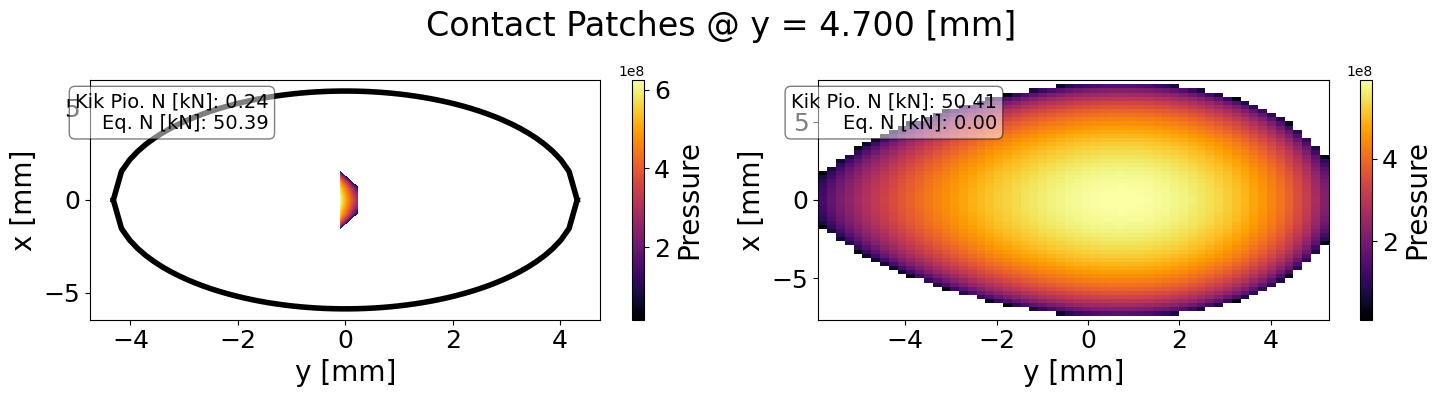

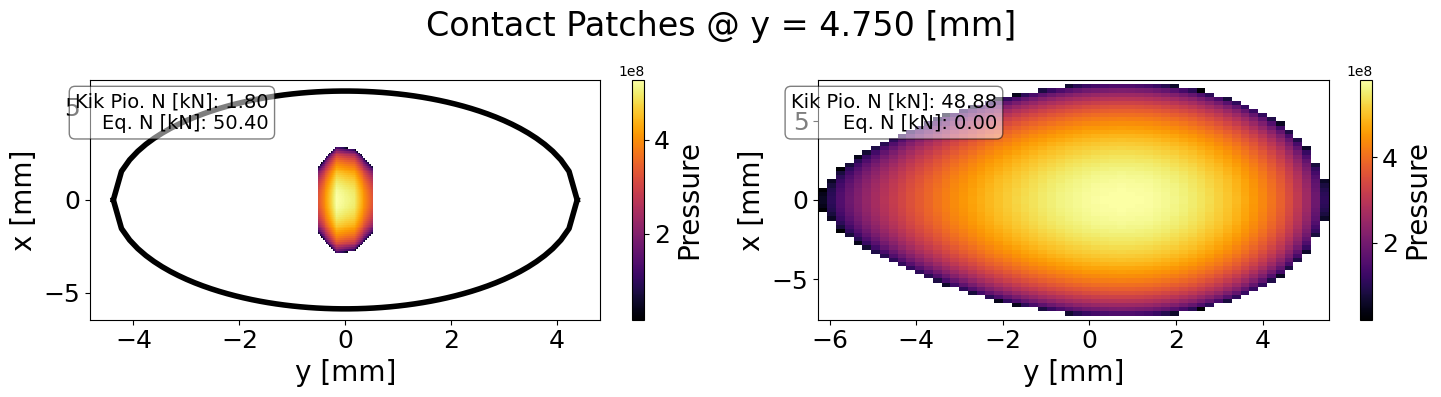

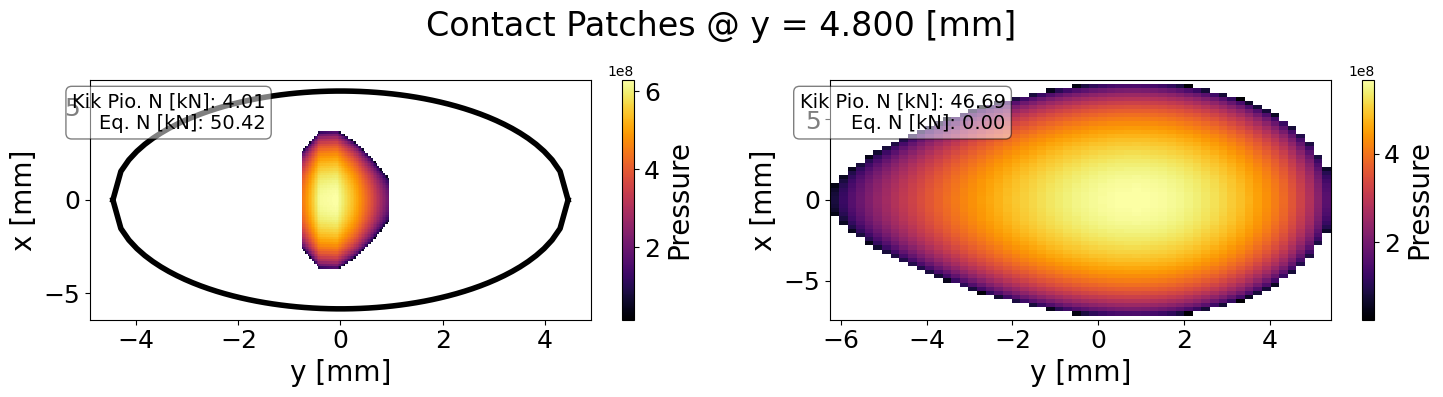

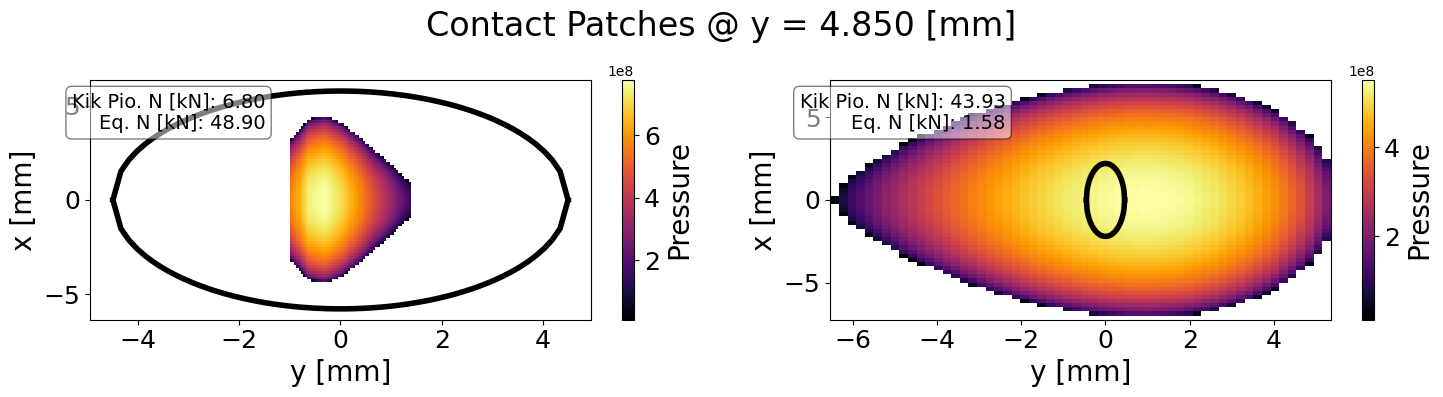

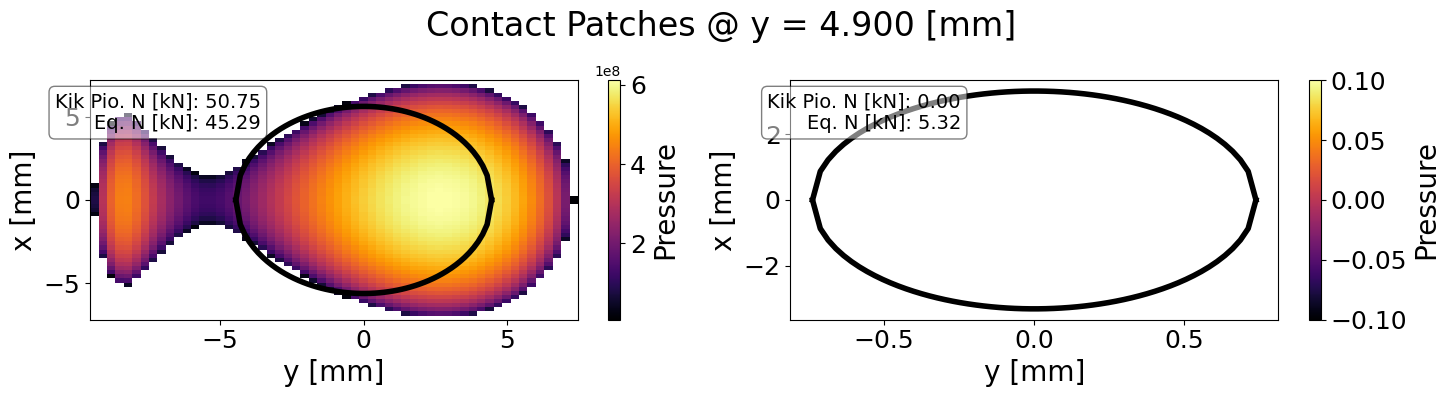

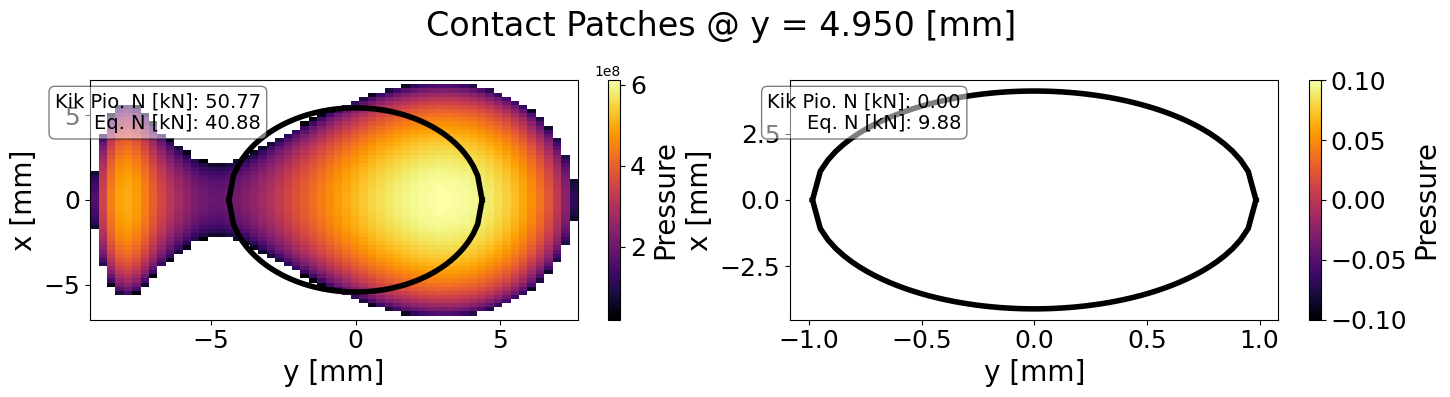

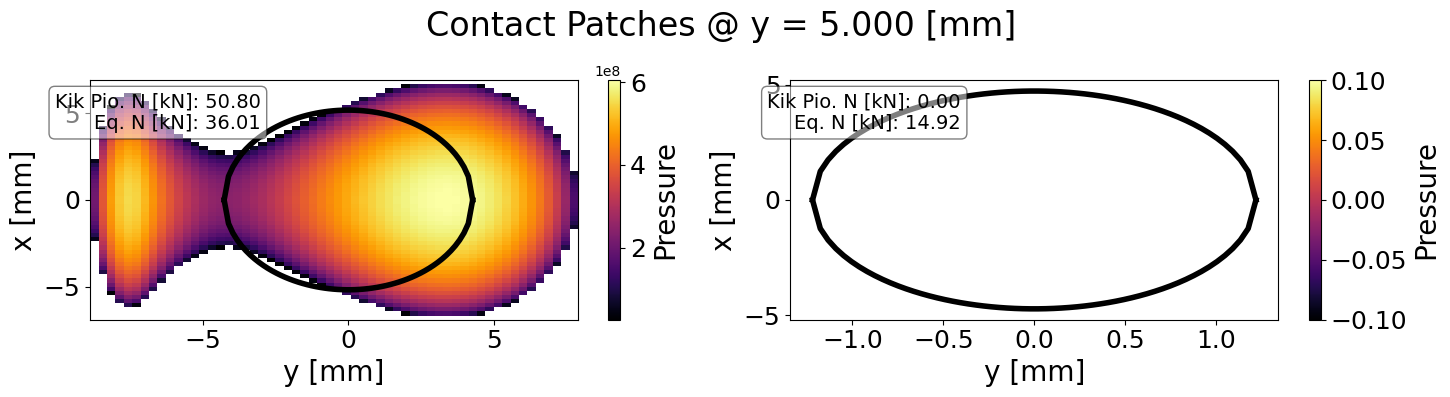

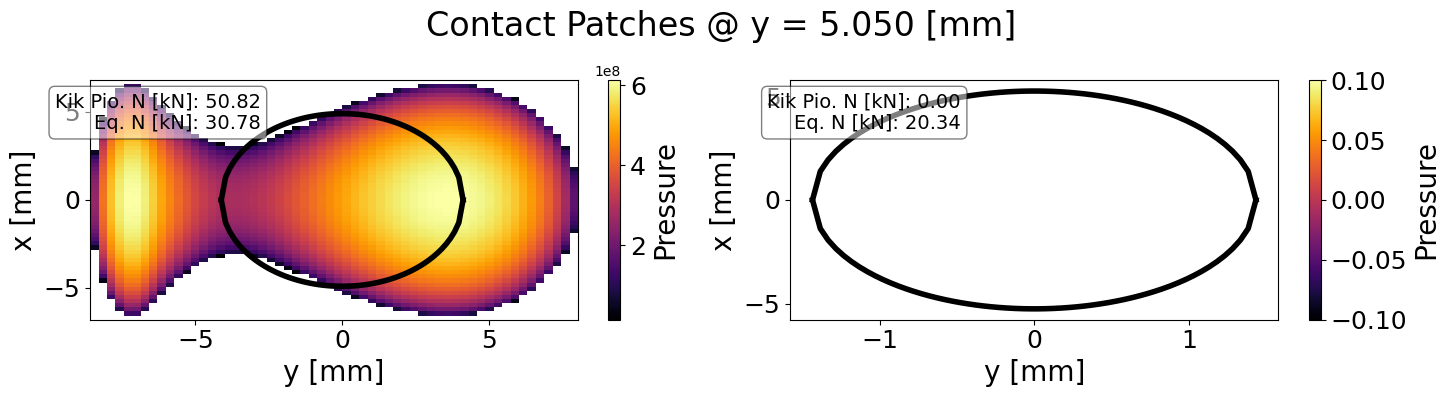

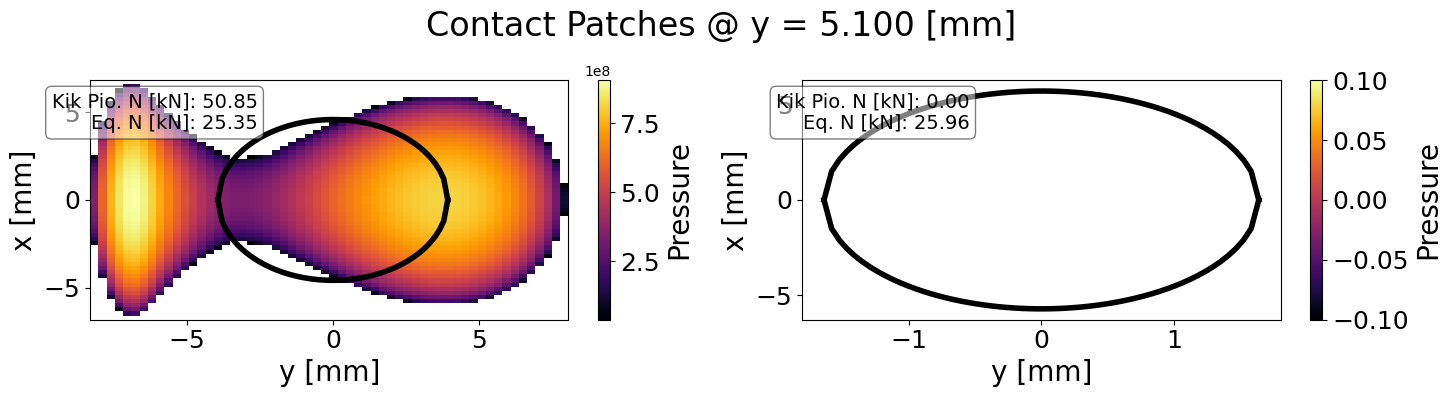

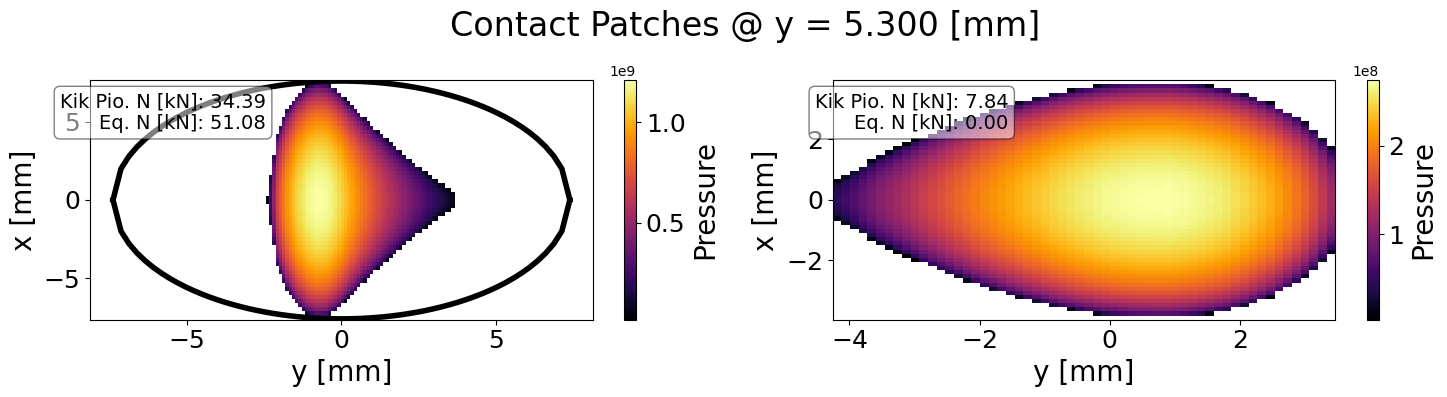

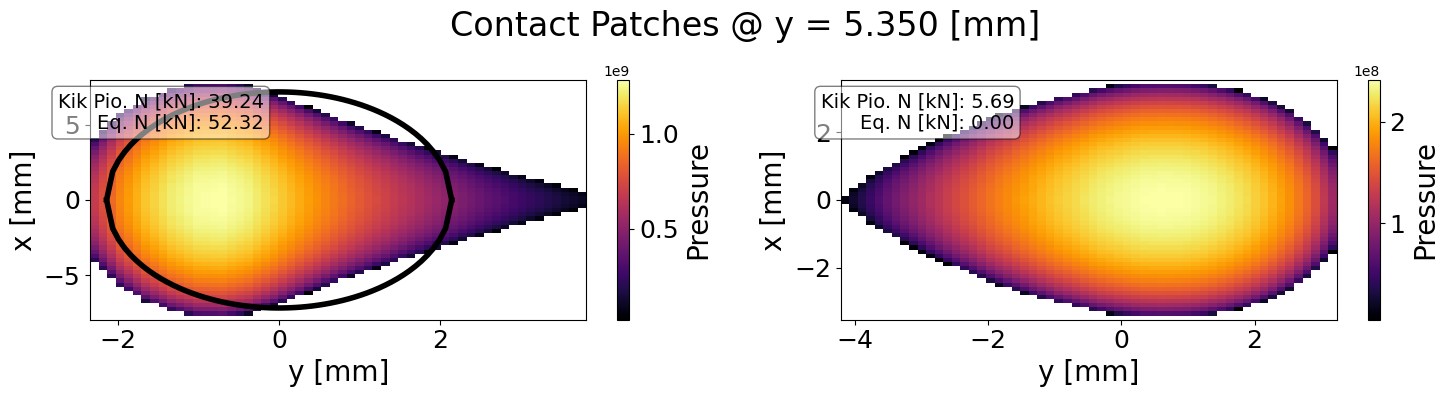

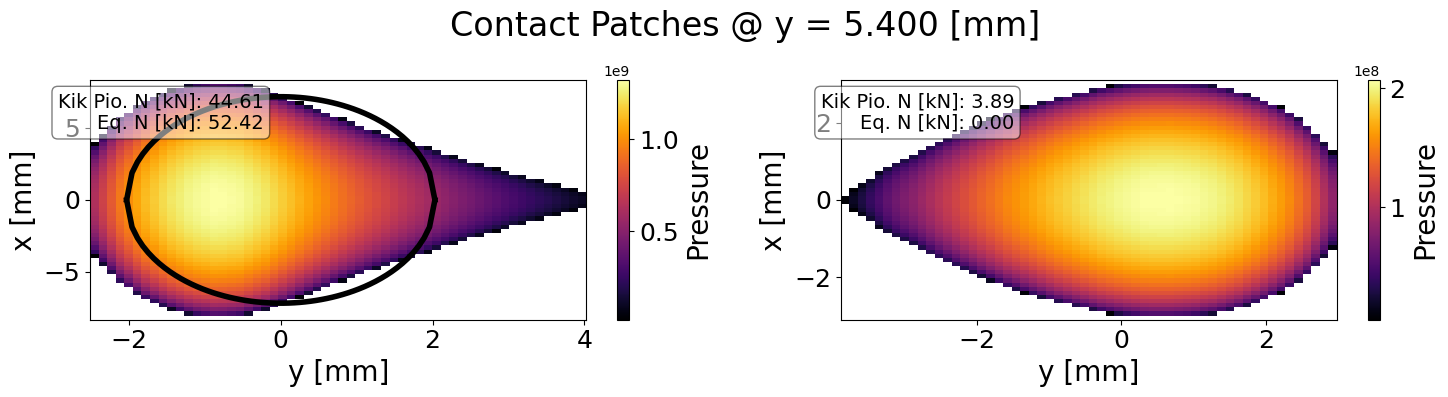

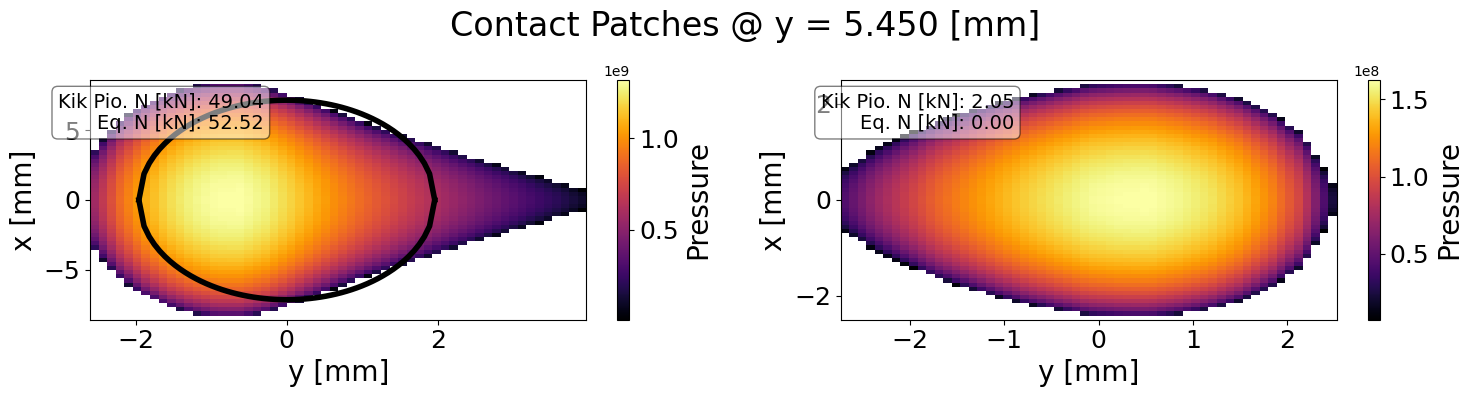

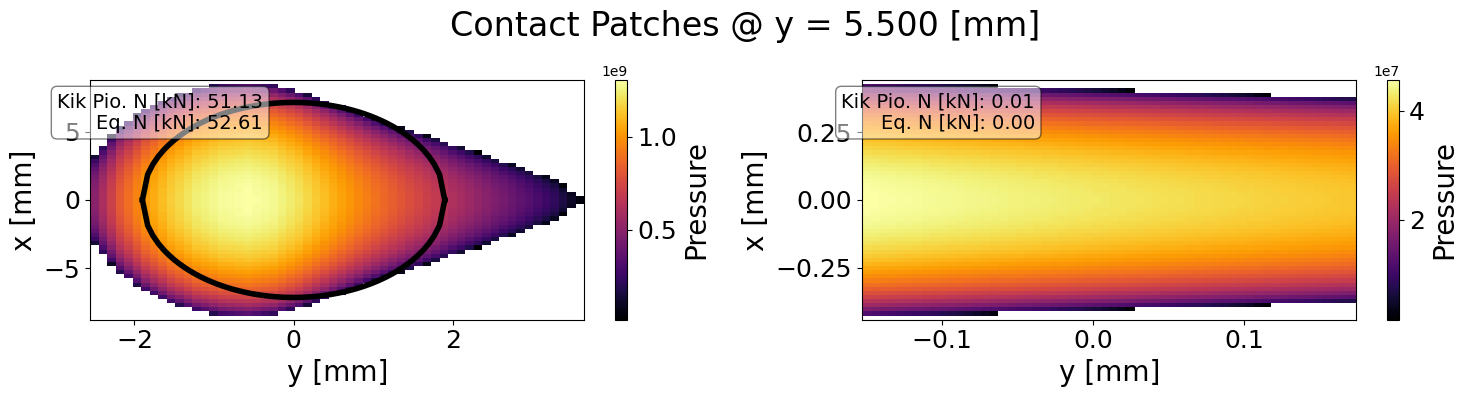

In [16]:
indexes_eq = list(np.where(patches_per_deltays_eq["patch_1"][:, 4] != 0)[0])
indexes_kp = list(np.where(patches_per_deltays_kp["patch_3"][:, 4] != 0)[0])
two_contacts_indexes = list(set(indexes_kp + indexes_eq))

for jj in range(len(two_contacts_indexes)):

    plot(
        patches_per_deltays_kp,
        result_state_pressure_kp,
        patches_per_deltays_eq,
        deltays,
        two_contacts_indexes[jj],
    )